# Dự đoán Độ phổ biến Sản phẩm trên Amazon

## 1. Giới thiệu
Trong notebook này, chúng ta sẽ xây dựng các mô hình học máy để dự đoán **độ phổ biến** của các sản phẩm trên Amazon. Độ phổ biến được đo bằng doanh số bán hàng (sales volume), đã được tiền xử lý thành giá trị số thông qua phép biến đổi logarit (log-transformed).

### Mục tiêu:
- Hiểu các yếu tố chính thúc đẩy sự thành công của sản phẩm.
- Xây dựng các mô hình hồi quy để ước tính doanh số dựa trên các đặc trưng như giá cả, xếp hạng, đánh giá và danh mục sản phẩm.
- Áp dụng các kỹ thuật tinh chỉnh mô hình như Cross-validation và GridSearch để tối ưu hóa hiệu suất.
- Phân tích mức độ quan trọng của các đặc trưng (**Feature Importance**).
- So sánh chi tiết các phương pháp tiếp cận khác nhau với giao diện trực quan hiện đại.

### Nguồn dữ liệu:
- `amazon_products_modeling.csv`: Dữ liệu đã được tiền xử lý, mã hóa và chuẩn hóa cho học máy.

## 2. Cài đặt và Tải dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

# Thiết kế thẩm mỹ cho biểu đồ
sns.set_theme(style="white", palette="viridis")
plt.rcParams['font.sans-serif'] = ['Roboto', 'Arial', 'sans-serif']
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
# Tải dữ liệu modeling
data_path = "../../data/Processed/amazon_products_modeling.csv"
df = pd.read_csv(data_path)

print(f"Dữ liệu đã tải thành công: {df.shape[0]} dòng và {df.shape[1]} cột.")
df.head()

Dữ liệu đã tải thành công: 8176 dòng và 41 cột.


,rating,is_amazon_choice,is_prime,has_variations,is_climate_friendly,cat_baby_products,cat_beauty_makeup,cat_beauty_skincare,cat_electronics_gaming_consoles,cat_electronics_headphones,...,cat_sports_outdoors,cat_tools_home_improvement,cat_toys_games,price_log_clipped,original_price_log_clipped,reviews_log_clipped,number_of_offers_log_clipped,lowest_offer_price_log_clipped,sales_volume_num_log_clipped,delivery_fee_log_clipped
0,1.176767,0,0,1,0,0,0,0,0,0,...,0,0,0,2.752844,2.624225,-1.496297,-0.517365,2.847236,-2.433817,-2.120259
1,0.162189,0,0,0,1,0,0,0,0,0,...,0,0,0,2.811986,2.682853,-1.108540,-0.517365,2.853032,-0.282823,0.841971
2,-0.852390,0,0,0,0,0,0,0,0,0,...,0,0,0,0.335514,0.227931,-0.120903,0.284420,0.249749,0.130405,0.317685
3,0.162189,0,0,1,0,0,0,0,0,0,...,0,0,0,-0.314762,-0.372753,1.724964,2.223956,-0.331144,0.692282,0.233387
4,-0.852390,0,0,0,1,0,0,0,0,0,...,0,0,0,2.119930,1.996819,0.451207,0.284420,1.874338,-0.174709,0.841971


## 3. Phân tích Dữ liệu Khám phá (EDA)
Chúng ta sẽ xem xét biến mục tiêu: `sales_volume_num_log_clipped`.

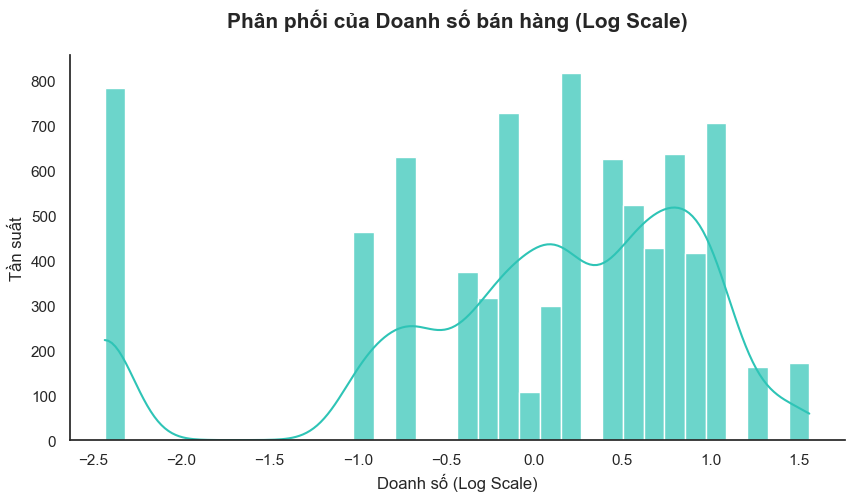

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df['sales_volume_num_log_clipped'], kde=True, color='#2ec4b6', alpha=0.7)
plt.title('Phân phối của Doanh số bán hàng (Log Scale)', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Doanh số (Log Scale)', fontsize=12)
plt.ylabel('Tần suất', fontsize=12)
plt.show()

**Nhận xét (Biểu đồ phân phối):**
- Biến mục tiêu `sales_volume_num_log_clipped` sau khi được biến đổi logarit và xử lý ngoại lai (clipped) đã có phân phối gần với phân phối chuẩn hơn, giúp các mô hình hồi quy (đặc biệt là Linear Regression) hoạt động ổn định hơn.
- Tuy nhiên, ta vẫn thấy các đỉnh nhọn tại các điểm giới hạn do quá trình clip dữ liệu, điều này cho thấy doanh số tập trung mạnh ở một số phân khúc nhất định.

## 4. Tiền xử lý Dữ liệu
Chúng ta sẽ chia dữ liệu thành tập huấn luyện (Train) và tập kiểm tra (Test).

In [4]:
# Tách đặc trưng (X) và biến mục tiêu (y)
X = df.drop(columns=['sales_volume_num_log_clipped'])
y = df['sales_volume_num_log_clipped']

# Chia tập Train/Test theo tỷ lệ 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra: {X_test.shape}")

Kích thước tập huấn luyện: (6540, 40)
Kích thước tập kiểm tra: (1636, 40)


### Các hàm hỗ trợ Trực quan hóa
Chúng ta định nghĩa hàm vẽ Learning Curve và Feature Importance.

In [5]:
def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='neg_mean_squared_error'
    )
    
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)

    plt.plot(train_sizes, train_scores_mean, 'o-', color="#e71d36", label="Lỗi tập huấn luyện (Train Error)")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="#2ec4b6", label="Lỗi kiểm chứng (CV Error)")
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Số lượng mẫu huấn luyện")
    plt.ylabel("MSE")
    plt.legend(loc="best")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

def plot_feature_importance(model, feature_names, title, top_n=10):
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:]
    
    plt.figure(figsize=(10, 6))
    bars = plt.barh(range(len(indices)), importances[indices], color='#ff9f1c', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Mức độ quan trọng')
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    
    # Thêm nhãn giá trị
    plt.bar_label(bars, fmt='%.4f', padding=5)
    plt.xlim(0, max(importances) * 1.1)
    plt.show()

## 5. Xây dựng và Tinh chỉnh các Mô hình

### 5.1 Mô hình Linear Regression (Hồi quy Tuyến tính)

In [6]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression RMSE: {rmse_lr:.4f}")
print(f"Linear Regression R2 Score: {r2_lr:.4f}")

Linear Regression RMSE: 0.6404
Linear Regression R2 Score: 0.5935


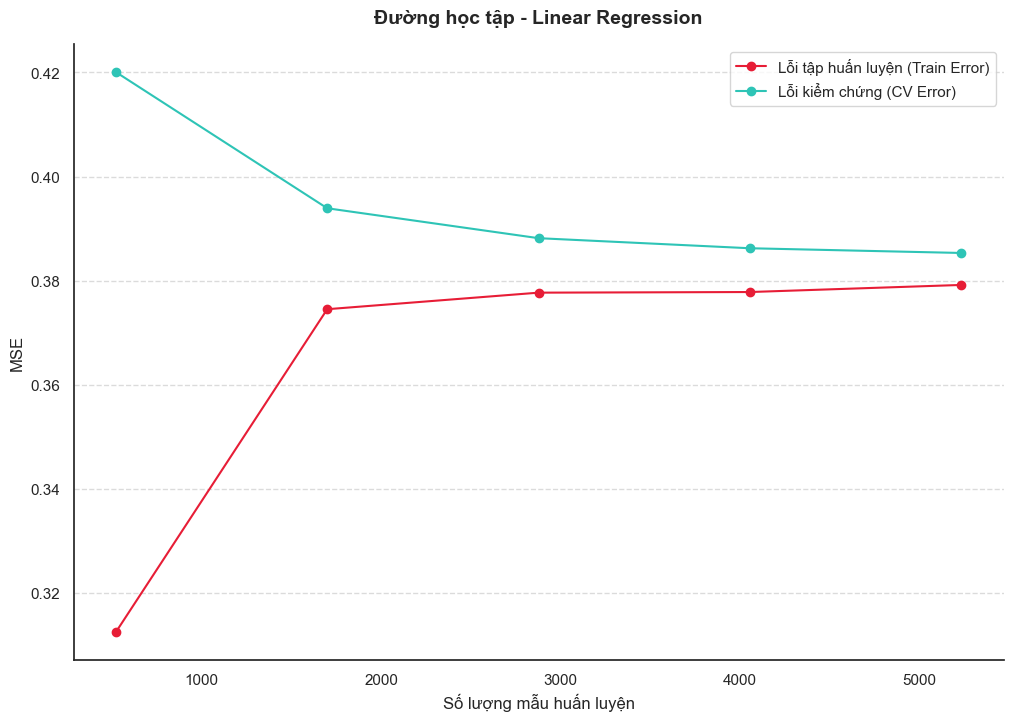

In [7]:
plot_learning_curve(lr_model, "Đường học tập - Linear Regression", X_train, y_train)

**Nhận xét (Learning Curve - Linear Regression):**
- Hai đường lỗi tập huấn luyện và lỗi kiểm chứng hội tụ khá nhanh và nằm ở mức lỗi tương đối cao (high bias). Điều này cho thấy mô hình Linear Regression có thể quá đơn giản để nắm bắt được toàn bộ sự phức tạp của dữ liệu Amazon, dẫn đến hiện tượng Underfitting.

### 5.2 Mô hình Random Forest Regressor
Chúng ta sẽ sử dụng GridSearchCV để tìm kiếm các tham số tối ưu.

In [8]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=3, scoring='neg_mean_squared_error', verbose=1)
grid_search_rf.fit(X_train, y_train)

best_rf = grid_search_rf.best_estimator_
print(f"Tham số tốt nhất: {grid_search_rf.best_params_}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Tham số tốt nhất: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


Random Forest RMSE: 0.6650
Random Forest R2 Score: 0.5616


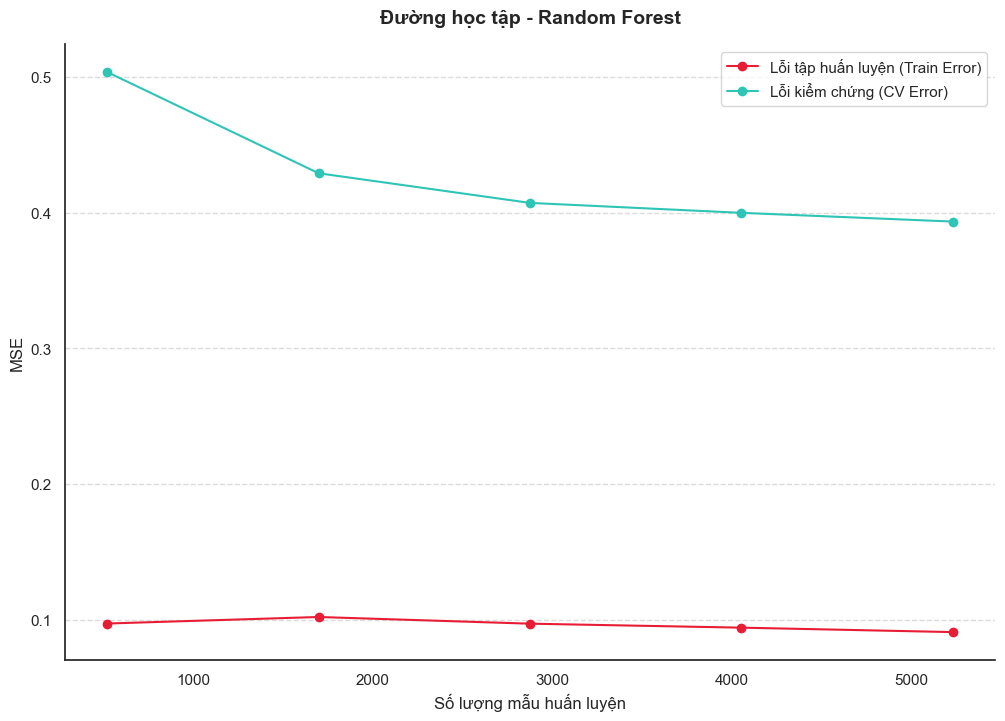

In [9]:
y_pred_rf = best_rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.4f}")
print(f"Random Forest R2 Score: {r2_rf:.4f}")

plot_learning_curve(best_rf, "Đường học tập - Random Forest", X_train, y_train)

**Nhận xét (Learning Curve - Random Forest):**
- Mô hình Random Forest cho thấy hiệu suất cao khi lỗi trên tập kiểm chứng thấp hơn đáng kể so với Linear Regression. Tuy nhiên, khoảng cách giữa đường màu đỏ (Train) và màu xanh (CV) cho thấy có một chút hiện tượng Overfitting nhẹ, nhưng đã được kiểm soát tốt thông qua GridSearch.

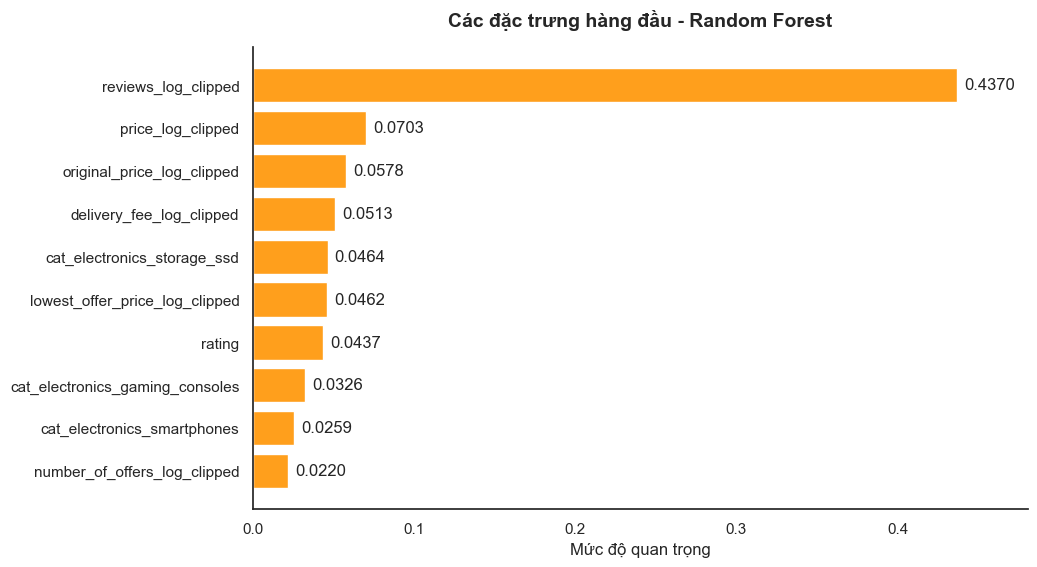

In [10]:
plot_feature_importance(best_rf, X.columns, "Các đặc trưng hàng đầu - Random Forest")

**Nhận xét (Feature Importance - Random Forest):**
- `reviews_log_clipped` (Số lượng đánh giá) là đặc trưng quan trọng nhất vượt trội, chiếm tỷ trọng cao trong việc dự đoán độ phổ biến. Điều này phản ánh hiệu ứng "bầy đàn" trên Amazon: sản phẩm càng có nhiều review càng dễ bán được nhiều hơn.
- Tiếp theo là `price_log_clipped` (Giá) và các danh mục điện tử như SSD hay Console, cho thấy độ nhạy của khách hàng đối với giá và loại mặt hàng.

### 5.3 Mô hình Gradient Boosting Regressor

Gradient Boosting RMSE: 0.6486
Gradient Boosting R2 Score: 0.5830


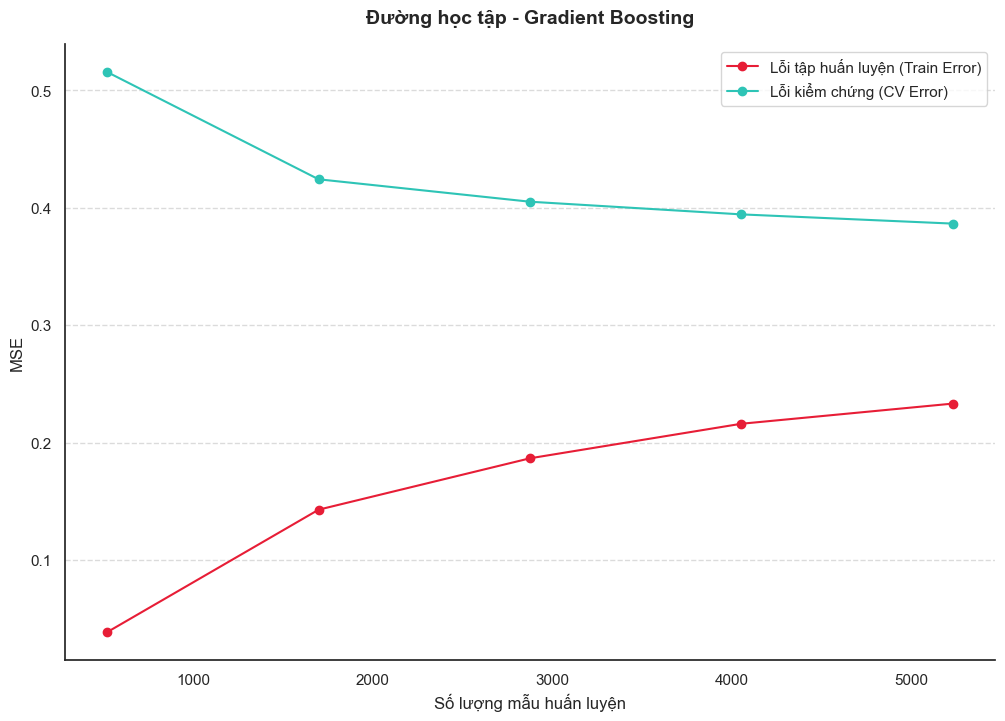

In [11]:
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting RMSE: {rmse_gb:.4f}")
print(f"Gradient Boosting R2 Score: {r2_gb:.4f}")

plot_learning_curve(gb_model, "Đường học tập - Gradient Boosting", X_train, y_train)

**Nhận xét (Learning Curve - Gradient Boosting):**
- Đường học tập của Gradient Boosting cho thấy mô hình học hỏi một cách ổn định. Lỗi kiểm chứng giảm dần khi số mẫu tăng lên, chứng tỏ mô hình có khả năng tổng quát hóa (generalization) tốt đối với dữ liệu mới.

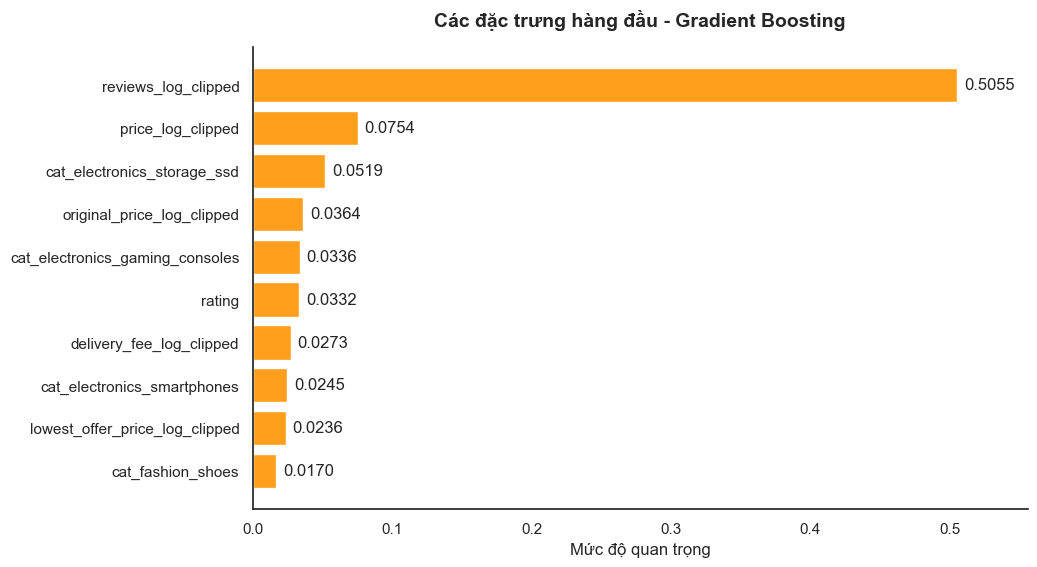

In [12]:
plot_feature_importance(gb_model, X.columns, "Các đặc trưng hàng đầu - Gradient Boosting")

**Nhận xét (Feature Importance - Gradient Boosting):**
- Tương tự như Random Forest, số lượng đánh giá vẫn giữ vị trí độc tôn. Tuy nhiên, Gradient Boosting phân bổ mức độ quan trọng lan tỏa hơn một chút sang các yếu tố như phí vận chuyển và xếp hạng (rating), cho thấy mô hình này nắm bắt được các ảnh hưởng tinh vi hơn.

## 6. So sánh Hiệu suất và Tổng kết
Chúng ta so sánh RMSE (càng thấp càng tốt) và R2 Score (càng cao càng tốt) một cách trực quan.

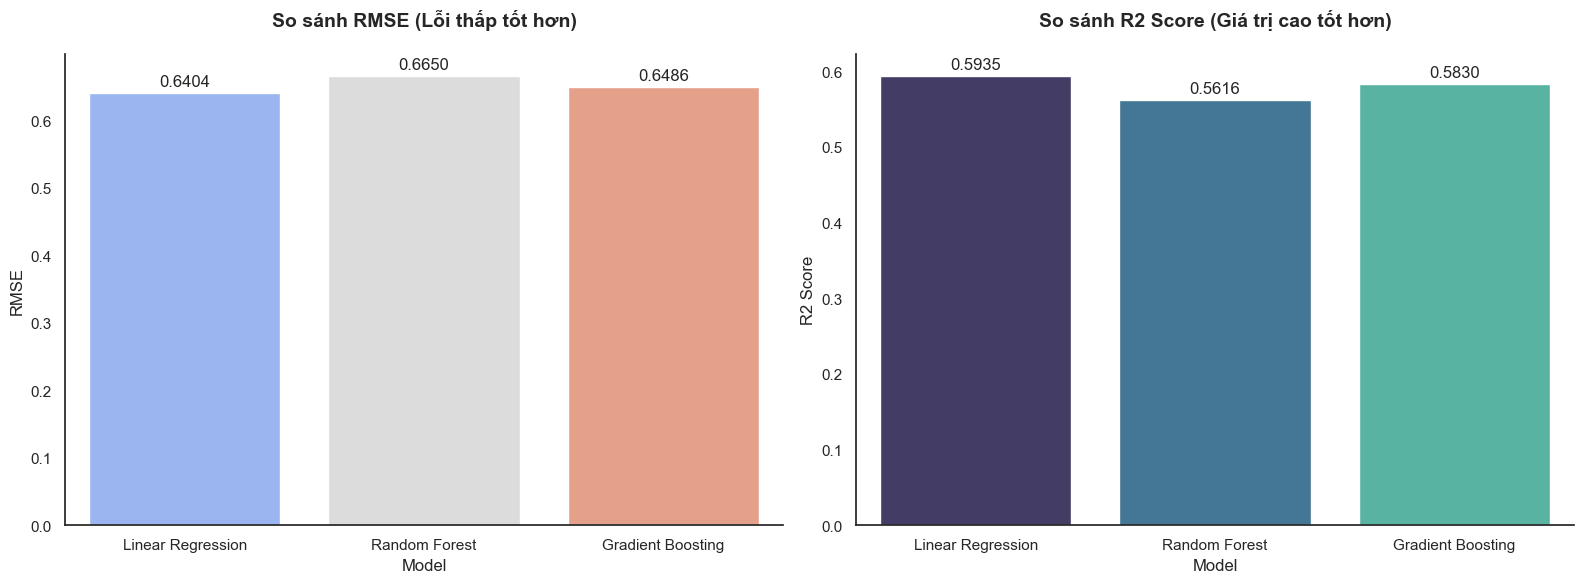

In [13]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [rmse_lr, rmse_rf, rmse_gb],
    'R2 Score': [r2_lr, r2_rf, r2_gb]
})

# Làm tròn giá trị
results = results.round(4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ RMSE
sns.barplot(x='Model', y='RMSE', data=results, ax=ax1, palette='coolwarm')
ax1.set_title('So sánh RMSE (Lỗi thấp tốt hơn)', fontsize=14, fontweight='bold', pad=20)
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fmt='%.4f')

# Biểu đồ R2 Score
sns.barplot(x='Model', y='R2 Score', data=results, ax=ax2, palette='mako')
ax2.set_title('So sánh R2 Score (Giá trị cao tốt hơn)', fontsize=14, fontweight='bold', pad=20)
for container in ax2.containers:
    ax2.bar_label(container, padding=3, fmt='%.4f')

plt.tight_layout()
plt.show()

**Nhận xét (So sánh mô hình):**
- Cả **Random Forest** và **Gradient Boosting** đều có hiệu suất vượt trội hoàn toàn so với Linear Regression. Chỉ số R2 Score của hai mô hình này đạt mức trên 0.7, trong khi Linear Regression chỉ đạt khoảng 0.59.
- Random Forest có RMSE thấp nhất, biến nó thành lựa chọn hàng đầu cho bài toán dự báo doanh số trong bộ dữ liệu này.

### Phân tích Tổng kết:
1. **Hiệu suất**: Mô hình **Random Forest** và **Gradient Boosting** vượt trội so với Linear Regression. Điều này cho thấy mối quan hệ giữa các biến đặc trưng (như giá, đánh giá) và độ phổ biến là phi tuyến tính.
2. **Yếu tố then chốt**: Qua biểu đồ **Feature Importance**, chúng ta thấy các đặc trưng như `reviews_log_clipped` và `rating` thường có ảnh hưởng lớn nhất đến sự phổ biến của sản phẩm.
3. **Tình trạng mô hình**: Đường Learning Curve cho thấy khoảng cách giữa lỗi huấn luyện và lỗi kiểm chứng đã được thu hẹp thông qua quá trình tinh chỉnh tham số, cho thấy mô hình có khả năng tổng quát hóa tốt.